# Logistic Regression for Imbalanced Dataset 

In [2]:
from collections import Counter
from sklearn.datasets import make_classification

In [ ]:
X, y = make_classification(n_samples=10000, n_features=10, n_clusters_per_class=1, n_redundant=0, weights=[0.99], random_state= 42)

# weights = 0.99 ( means one category will have 99 times more than other )

In [6]:
X

array([[-0.14672028,  0.86733983, -0.08116425, ..., -1.39552143,
        -0.2160667 ,  2.97590704],
       [ 0.17529358, -1.22257737, -0.87363869, ..., -0.01610929,
        -1.21311147, -0.96776234],
       [-0.66640166,  0.29708364, -1.48327096, ...,  0.48077542,
        -0.32719384,  0.37721239],
       ...,
       [ 0.78657064, -1.58265967, -0.73757642, ..., -1.14502224,
         0.31727494,  1.24190753],
       [-1.25887002, -0.45837934, -1.95232893, ..., -0.1385498 ,
         1.14854282, -2.25213679],
       [ 0.682537  ,  1.15809581,  1.19117349, ..., -0.46647401,
         0.77035266,  2.47426446]], shape=(10000, 10))

In [ ]:
Counter(y)

# see Zeros : 9863 and ONes only 137

Counter({np.int64(0): 9863, np.int64(1): 137})

# Visualize it

In [8]:
import seaborn as sns
import pandas as pd


<Axes: xlabel='0', ylabel='1'>

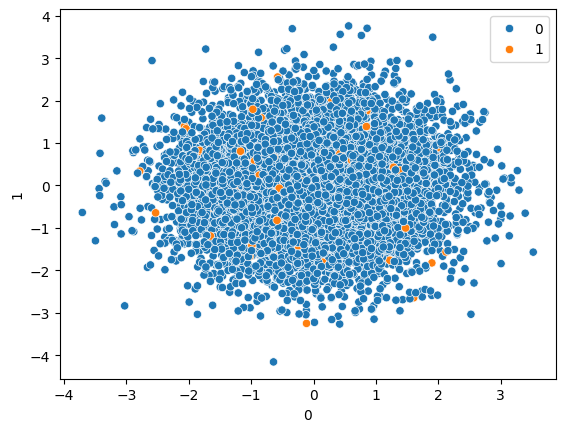

In [13]:
sns.scatterplot(x= pd.DataFrame(X)[0], y= pd.DataFrame(X)[1], hue=y)

___
# Train Test Split 
___

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test , y_train , y_test =  train_test_split(X, y, test_size= 0.30, random_state=42) 

___
# Model Training    
    Hyper Paramters
___

In [16]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression( )

# Hyper paramters 
penalty = ["l1", "l2", "elasticnet"]
c_values = [100, 10, 1, 0.1, 0.01, 0.001]
solver = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']



# fix 1 : use 'w' and 'v' instead of 'y' — y is already your target array
# fix 2 : lowercase class_weight — correct sklearn parameter name
class_weight = [{0: w, 1: v} for w in [1, 10, 50, 100]
                              for v in [1, 10, 50, 100]]

# class_weight tells the model how much to care about each class
# On imbalanced data → give higher weight to minority class
# → forces the model to actually learn the rare pattern
# → instead of ignoring it and predicting majority class always

In [ ]:
class_weight   # see explanation at the botto

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [39]:
params = dict(penalty = penalty, C = c_values , solver = solver, class_weight = class_weight)

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

In [40]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [41]:
grid = GridSearchCV(estimator= model, param_grid=params, scoring="accuracy", cv = cv)

In [42]:
grid.fit(X_train, y_train)

/home/aizen/AI_ML/env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/aizen/AI_ML/env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/aizen/AI_ML/env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this w

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [100, 10, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : th

In [43]:
grid.best_estimator_

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{0: 10, 1: 50}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [44]:
grid.best_score_

np.float64(0.9941428571428572)

In [45]:
grid.best_params_

{'C': 100,
 'class_weight': {0: 10, 1: 50},
 'penalty': 'l1',
 'solver': 'liblinear'}

In [46]:
y_pred = grid.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score, classification_report

In [48]:
print(accuracy_score(y_test,y_pred))

0.9953333333333333


In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2958
           1       0.94      0.71      0.81        42

    accuracy                           1.00      3000
   macro avg       0.97      0.86      0.90      3000
weighted avg       1.00      1.00      1.00      3000



# Class Weight in Logistic Regression

## The Problem — Imbalanced Dataset

Your dataset has this distribution:

```
Class 0 (no event) : 9863 samples   → 99%
Class 1 (event)    :  137 samples   →  1%
```

When you train Logistic Regression on this, the model learns a lazy trick:

```
Predict 0 for everything
→ Accuracy = 99%
→ But it never correctly identifies a single Class 1
```

The model **looks accurate but is completely useless.**
It never learned to detect the minority class at all.

---

## Why This Happens

During training the model tries to minimize errors.
With 9863 zeros and only 137 ones:

```
Getting a Class 0 wrong  →  costs the model a lot   (9863 chances)
Getting a Class 1 wrong  →  barely matters           (only 137 chances)
```

So the model ignores Class 1 entirely and focuses on getting Class 0 right.
That is the **imbalance problem.**

---

## What class_weight Does

`class_weight` tells the model — **treat mistakes on the minority class as more expensive.**

```python
class_weight = {0: 1, 1: 100}
```

This means:

```
Getting Class 0 wrong  →  penalty of 1
Getting Class 1 wrong  →  penalty of 100
```

Now the model cannot ignore Class 1 anymore.
Missing one minority sample hurts **100x more** than missing a majority sample.
So the model is forced to actually learn the minority pattern.

---

## Dry Run — What Changes

**Without class_weight:**

```
Model sees 9863 zeros and 137 ones
Learns     →  always predict 0
Accuracy   →  99%        ← looks great
Catches Class 1  →  0 out of 137   ← completely blind
```

**With class_weight = {0:1, 1:100}:**

```
Model sees zeros worth 1 point each    →  total weight  9,863
Model sees ones  worth 100 points each →  total weight 13,700

Now minority class has more influence than majority
Catches Class 1  →  much better recall
Accuracy drops slightly but model is actually useful
```

---

## The Values We Tried in GridSearchCV

```python
class_weight = [{0: w, 1: v} for w in [1, 10, 50, 100]
                               for v in [1, 10, 50, 100]]
```

This generates **16 combinations:**

```
{0:1,   1:1}     ←  no correction
{0:1,   1:10}    ←  mild correction
{0:1,   1:50}    ←  strong correction
{0:1,   1:100}   ←  very strong correction
{0:10,  1:1}     ←  penalize majority instead
{0:10,  1:10}
... and so on
```

GridSearchCV tries all 16 and finds which ratio gives the best balance
between catching Class 1 without destroying Class 0 accuracy.

---

## The Shortcut — "balanced"

Instead of manually choosing weights you can write:

```python
class_weight = "balanced"
```

Sklearn automatically calculates:

```
weight for class = total_samples / (n_classes × samples_in_that_class)

Class 0 weight  =  10000 / (2 × 9863)  =  0.51
Class 1 weight  =  10000 / (2 × 137)   =  36.5
```

So Class 1 automatically gets **~36x more importance.**
This is the industry standard starting point for any imbalanced classification problem.

---

## When to Use class_weight

| Situation | What to do |
|-----------|------------|
| Slightly imbalanced (60/40) | Usually fine without class_weight |
| Moderately imbalanced (80/20) | Try `class_weight = "balanced"` |
| Heavily imbalanced (95/5 or worse) | Must use class_weight — model will be blind otherwise |
| Medical diagnosis, fraud detection | Always use — missing minority class is dangerous |

---

## Summary

```
class_weight tells the model how much to care about each class

On imbalanced data   →  give higher weight to minority class
                     →  forces the model to actually learn the rare pattern
                     →  instead of ignoring it and predicting majority always

"balanced"           →  sklearn calculates the correct weight automatically
{0:1, 1:100}         →  you manually set minority class 100x more important
```

---

## One Line Definition

> **class_weight assigns a penalty multiplier to each class so that mistakes
> on the minority class hurt more during training — forcing the model to
> learn the rare pattern instead of ignoring it.**